# What Factors Are Associated With  Airbnb Prices and Performance Across London?
This project explores the factors that are associated with Airbnb listing prices across London. Using data on property characteristics, ratings, and host characteristics I will answer the following question:

#### How are location, property characteristics, host characteristics and guest ratings associated with Airbnb listing prices in London?
The aim is to find patterns in the data and identify which characteristics are most strongly associated with listing price.

## Data Loading

The following libraries are used throughout the project for data manipulation, visualisation, statistical analysis and machine learning. `pandas` and `numpy` are used to manipulate data, `seaborn` and `matplot` are used for visualisation, `scipy` is used for statistical analysis and `scikit-learn` is used for data preprocessing, creating a machine-learning pipeline and model development. 

In [1]:
# Dependencies
import pandas as pd
import numpy as np
import seaborn as sns

from matplotlib import pyplot as plt

from scipy.stats import spearmanr
from scipy.stats import ttest_ind

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

I will load the dataset into a pandas dataframe using `pd.read_csv()` and inspect its shapes with `.shape`. This will provide an initial overview of the listings as well as the number of features in the dataset.

In [2]:
listings = pd.read_csv('listings.csv')
print("The dataset contains {} listings and {} columns".format(listings.shape[0], listings.shape[1]))

The dataset contains 92638 listings and 90 columns


The dataset contains `92638` listings and `90` features, providing a substantial number of observations that I can use to evaluate the features associated with listing price.\
`90` features are too many for this analysis, so before continuing on to data cleaning I will inspect the names of each column and view a sample of the dataset. This will allow me to select the most important features to use for analysis in the coming section.

In [3]:
print(listings.columns)
listings.head()

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_profile_id', 'host_profile_url', 'host_name',
       'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'price_quote_checkin_date', 'price_quote_c

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,11551,https://www.airbnb.com/rooms/11551,20260619061251,2026-06-25,city scrape,Artistic London Pied-à-Terre,Live like a local in this quintessential Londo...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,43039,...,4.84,4.54,4.49,NaN,NaN,1,1,0,0,0.99
1,13913,https://www.airbnb.com/rooms/13913,20260619061251,2026-06-25,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,4.88,4.79,4.79,NaN,NaN,2,1,1,0,0.30
2,15400,https://www.airbnb.com/rooms/15400,20260619061251,2026-06-26,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,NaN,https://a0.muscache.com/pictures/428392/462d26...,60302,...,4.84,4.94,4.74,NaN,NaN,1,1,0,0,0.49
3,17402,https://www.airbnb.com/rooms/17402,20260619061251,2026-06-29,city scrape,Spacious Fitzrovia 3bed/2bath By Soho & Oxford St,"Stay in this spacious 3-bedroom, 2-bath apartm...",NaN,https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,4.73,4.89,4.62,NaN,NaN,2,2,0,0,0.31
4,513198,https://www.airbnb.com/rooms/513198,20260619061251,2026-06-29,city scrape,Stunning views over Central London! (room),Wake up to the sound of Big Ben!<br /><br />Th...,NaN,https://a0.muscache.com/pictures/6442310/e4b3e...,2528030,...,4.74,4.72,4.42,NaN,NaN,2,1,1,0,0.25


## Data Cleaning

The original dataset contains 90 columns, many of which are not relevant for analyzing the factors that are related to Airbnb pricings. I therefore selected a subset of the dataframe that I will use to analyze the factors that are associated with a listing's price. With the selected features, I created a new dataframe called `df`, that I will use for the subsequent EDA and modelling. 

The selected features include the target variable, `price`, as well as `neighbourhood_cleansed` and `room_type` to represent location and property characteristics, `accommodates`, `bedrooms`, `bathrooms`, `beds` to describe the property, `host_is_superhost` and `hosts_time_as_host_years` for host characteristics, and `review_scores_rating` for user reviews. These features will form the basis of my analysis.

In [4]:
analysis_cols = ['price',
    'neighbourhood_cleansed',
    'property_type',
    'room_type',
    'accommodates',
    'bedrooms',
    'bathrooms',
    'beds',
    'host_is_superhost',
    'hosts_time_as_host_years',
    'review_scores_rating'
    ]
# Create the df used for analysis
df = listings[analysis_cols].copy()

df.head()


,price,neighbourhood_cleansed,property_type,room_type,accommodates,bedrooms,bathrooms,beds,host_is_superhost,hosts_time_as_host_years,review_scores_rating
0,$234.50,Lambeth,Entire rental unit,Entire home/apt,5,1.0,1.0,3.0,t,15.0,4.55
1,$127.00,Islington,Private room in rental unit,Private room,1,NaN,1.0,1.0,f,15.0,4.86
2,$137.50,Kensington and Chelsea,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,f,15.0,4.81
3,$606.67,Westminster,Entire rental unit,Entire home/apt,6,3.0,2.0,3.0,t,15.0,4.77
4,$68.30,Lambeth,Private room in rental unit,Private room,1,1.0,1.5,1.0,f,14.0,4.42


To begin the data cleaning I will inspect the missing data in the dataframe. As opposed to simply using `isna().sum()`, I will instead create a dataframe of the missing data, showing both the number of null values for each feature as well as the proportion of the data that is missing. This will help determine which features require further cleaning and investigation.

In [5]:
missing = pd.DataFrame({"Missing Count": df.isna().sum(), "Missing Proportion": df.isna().mean()*100}).sort_values(by="Missing Proportion", ascending=False)
missing

,Missing Count,Missing Proportion
bathrooms,34876,37.647618
beds,32475,35.055809
price,30398,32.813748
bedrooms,23983,25.888944
review_scores_rating,21927,23.669552
hosts_time_as_host_years,77,0.083119
host_is_superhost,76,0.082040
neighbourhood_cleansed,0,0.000000
property_type,0,0.000000
room_type,0,0.000000


The `missing` dataframe shows that several features contain a significant proportion of missing values. `bathrooms` has the highest proportion of missing values at `~37.6%`, followed by `beds` with `~35%`, `price` with `32.8%`, `bedrooms` with `~25.9%` and `review_scores_rating` with `~23.7%` missing values. Contrastingly, `hosts_time_as_years` and `host_is_superhost` both have very few missing values, with each only accounting for `~0.08%` of the dataset. The rest of the features contain no missing values. 

I will investigate the missing values of each feature before deciding how I will handle them. 

#### Price

Given that `price` will be our target variable, it makes sense to clean this first. I can see that there is a `$` sign on each observation, and some of the larger values also have a `,`, so I will use pandas `replace()` function to remove this punctuation from the observations. Given that there is punctuation, it's also clear that it is being stored as a `string` datatype, so I will convert it to `float`.

In [6]:
# check for formatting
df[df['price'].str.contains(',')].head(5)

,price,neighbourhood_cleansed,property_type,room_type,accommodates,bedrooms,bathrooms,beds,host_is_superhost,hosts_time_as_host_years,review_scores_rating
92,"$1,037.00",Wandsworth,Private room in rental unit,Private room,1,1.0,NaN,NaN,f,14.0,5.00
231,"$1,500.00",Lewisham,Entire home,Entire home/apt,6,3.0,NaN,NaN,f,14.0,NaN
423,"$2,006.67",Lambeth,Private room in rental unit,Private room,2,NaN,1.0,1.0,f,14.0,5.00
1007,"$1,150.00",Hammersmith and Fulham,Private room in loft,Private room,2,1.0,1.0,1.0,f,13.0,4.75
1212,"$1,142.33",Kensington and Chelsea,Entire home,Entire home/apt,6,NaN,NaN,5.0,f,12.0,4.71


In [7]:
#strip 'price' of punctuation
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
#convert to float
df['price'] = df['price'].astype(float)
print(df['price'].dtype)
df[['price']].head()

float64


,price
0,234.50
1,127.00
2,137.50
3,606.67
4,68.30


To better understand the distribution of `price`, which is the outcome variable, I will calculate summary statistics and examine the upper percentiles. This will provide an overview of the typical listing prices while also showing how prices vary among the top percentiles. Examining the top percentiles will help determine whether they are unusually high prices that warrant further investigation. 

In [8]:
df['price'].describe(percentiles=[.50, .90, .95, .99, .995, .999])

count     62240.000000
mean        271.469220
std        2190.599006
min           2.230000
50%         180.000000
90%         488.020000
95%         676.000000
99%        1373.457500
99.5%      2008.183350
99.9%      6234.065870
max      527524.000000
Name: price, dtype: float64

The summary statistics show a substantial difference between the `median` of the `price` variable (`~$180`) and the `mean` (`~$271.47`). The mean being significantly higher than the median suggests that the data is right-skewed, with a small proportion of higher-priced listings pulling the mean up. 

The upper percentiles of the dataset also display a sharp increase in price amongst the listings. While `99.5%` of the dataset is listed at or below `$2008`, the `99.9th` percentile is listed at `~$6234` and the maximum value is significantly higher still, being listed at a staggering `$527524`!. The large distance between the `99.9th percentile` and the `max value` suggests there are extreme outliers in the dataset that need to be investigated further.

To investigate the extreme outliers in the dataset, I filtered the dataframe to contain listings with a value of `≥$5000`. Several unusually high pricings can be seen, including the max value of `$527524.0`. Several listings have characteristics that could explain their high price, such as listing `57946` that costs `$19150.0` per night but is a luxury villa accommodating 16 people. However, there are also several listings that have an unusually high price despite having a relatively small capacity. I will explore those values further before deciding whether they represent genuine high-end listings or anomalous values. 

In [9]:
pd.set_option('display.max_rows', None)
df.loc[df['price']> 5000].sort_values(by='price', ascending=False).head(15)

,price,neighbourhood_cleansed,property_type,room_type,accommodates,bedrooms,bathrooms,beds,host_is_superhost,hosts_time_as_host_years,review_scores_rating
67130,527524.0,Tower Hamlets,Entire rental unit,Entire home/apt,1,1.0,NaN,1.0,f,1.0,NaN
8400,75000.0,Kensington and Chelsea,Private room in rental unit,Private room,1,NaN,1.0,1.0,f,10.0,4.85
61588,59214.0,Lambeth,Private room in rental unit,Private room,3,NaN,1.0,2.0,f,8.0,4.50
57238,28000.0,Lambeth,Private room in rental unit,Private room,3,NaN,1.0,1.0,f,4.0,3.64
56041,23686.0,Lambeth,Private room in rental unit,Private room,3,NaN,1.0,1.0,f,8.0,4.25
57946,19150.0,Westminster,Entire villa,Entire home/apt,16,22.0,20.0,28.0,f,6.0,NaN
64156,16316.8,Westminster,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,f,4.0,5.00
56739,14744.0,Islington,Entire home,Entire home/apt,16,6.0,4.5,7.0,f,9.0,NaN
66648,13600.0,Westminster,Entire rental unit,Entire home/apt,2,1.0,1.0,2.0,f,4.0,NaN
34627,13209.0,Westminster,Entire serviced apartment,Entire home/apt,10,5.0,5.0,5.0,f,7.0,NaN


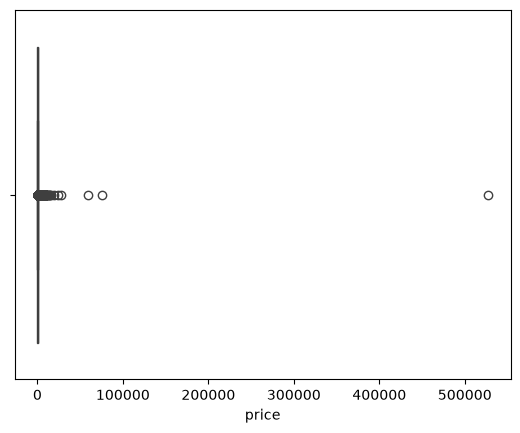

In [10]:
sns.boxplot(data=df, x='price')
plt.show()

The price distribution contains extreme outliers, the most egregious being `$527524.00` per night. This listing is listed at an extreme price compared to the rest of the dataset and appears inconsistent with its capacity for one guest. It also has no user reviews, and only accommodates a single person. The data suggests that it is listed at an arbitrarily high price in order to keep the property vacant, and its substantially higher value will distort analysis. With this in mind, I will drop it from the dataset. 


In [11]:
df = df.drop(index=67130)

Now that i've removed the extreme anomaly, I will plot the distribution of the `price` variable again to assess whether any further observations require investigation.

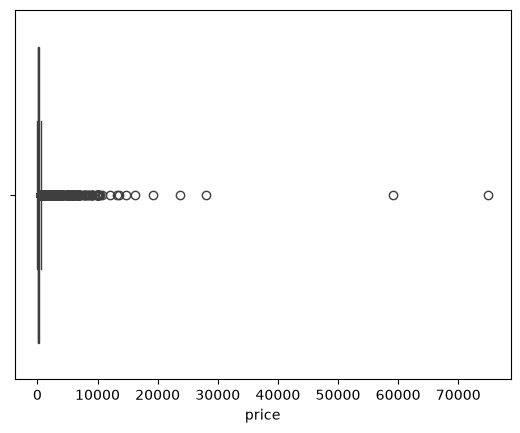

In [12]:
plt.clf()
sns.boxplot(data=df, x='price')

plt.show()

In [13]:
df.nlargest(20, 'price')[['price', 'room_type', 'accommodates', 'bedrooms', 'bathrooms']]

,price,room_type,accommodates,bedrooms,bathrooms
8400,75000.00,Private room,1,NaN,1.0
61588,59214.00,Private room,3,NaN,1.0
57238,28000.00,Private room,3,NaN,1.0
56041,23686.00,Private room,3,NaN,1.0
57946,19150.00,Entire home/apt,16,22.0,20.0
64156,16316.80,Entire home/apt,2,1.0,1.0
56739,14744.00,Entire home/apt,16,6.0,4.5
66648,13600.00,Entire home/apt,2,1.0,1.0
34627,13209.00,Entire home/apt,10,5.0,5.0
45042,12000.00,Entire home/apt,2,1.0,1.0


After removing the extreme anomaly, I briefly inspected the remaining high-priced listings along with their characteristics such as `room_type` and `bedrooms`. Although some of the listings have a relatively high price when compared to their size, it is not possible to determine from the available data whether they are errors or if they actually offer extreme luxury. I will therefore retain these values for the rest of the analyses. 

Before deciding how to handle the missing values in the target variable, `price`, I will first double check the number of null values.

In [14]:
missing.loc[['price']]

,Missing Count,Missing Proportion
price,30398,32.813748


There are `30398` null values in `price` feature, but before deciding how to handle them I will first investigate whether the missing values are associated with a specific `room_type`.

In [15]:
df[df['price'].isna()]['room_type'].value_counts()

room_type
Entire home/apt    19254
Private room       11052
Hotel room            72
Shared room           20
Name: count, dtype: int64

And now we compare them against the value counts of `room_type`

In [16]:
df['room_type'].value_counts()

room_type
Entire home/apt    61376
Private room       30878
Shared room          203
Hotel room           180
Name: count, dtype: int64

We can see that the null values for `price` are evenly spread across the dataset with no strong association to any room type. While `Entire home/apt` and `Private room` have a significantly higher number of null values, the two room types dominate the dataset so would naturally have a higher number of null values. 

Given that `price` is our target variable, we cannot simply impute their values without distorting our analyses. Consequently, I will drop them from the data. The dataset is large, so even though the null values have been dropped we will still be able to find some associations within the data. 

In [17]:
df = df.dropna(subset='price')
df['price'].isna().sum()

np.int64(0)

#### Bedrooms

The `bedrooms` feature contains a substantial amount of missing data. I will investigate this variable further before deciding how to handle the missing values, as there could be a pattern to the missingness. 

In [18]:
missing.loc['bedrooms']

Missing Count         23983.000000
Missing Proportion       25.888944
Name: bedrooms, dtype: float64

Given that bedrooms describes the room type of a property, I will compare the missing data in the `bedrooms` and `room_type` features to see if there is an association. To do this I will use the `crosstab()` function to visualise the proportion missing in each room type.

In [19]:
bedrooms_missing = pd.crosstab(df['room_type'], df['bedrooms'].isna(), normalize='index')
bedrooms_missing.columns = ['Not Missing', 'Missing']
bedrooms_missing

,Not Missing,Missing
room_type,,
Entire home/apt,0.955130,0.044870
Hotel room,0.925926,0.074074
Private room,0.405276,0.594724
Shared room,0.732240,0.267760


The results show that there is a strong association between the missing values of `bedrooms` and the feature `room_type`. While only `~4%` of the values are missing for `Entire home/apt`, there is a significant increase to `~26%` for `Shared room` and again a huge increase to `~59%` for `Private room`. This suggests that the missing values for `bedrooms` are not randomly distributed, so I will investigate whether other features can help explain the missingness. 

Given this pattern, simply imputing the median or mean for `bedrooms` would introduce bias into the data due to the missingness not being randomly distributed. Dropping the observations entirely would also limit the data that is available for the rest of the analyses. As the `bedrooms` feature is only required for analyses with its association to price, I will keep the missing values in the dataset and exclude them only when analysing bedrooms. 

#### Bathrooms

the `bathrooms` feature contains the highest proportion of missing values in the dataset. I will briefly investigate to see if there is a pattern to this missingness before deciding how to handle the missing values. 

In [20]:
missing.loc['bathrooms']

Missing Count         34876.000000
Missing Proportion       37.647618
Name: bathrooms, dtype: float64

In [21]:
bathrooms_missing = pd.crosstab(df['room_type'], df['bathrooms'].isna(), normalize='index')
bathrooms_missing.columns = ['Not Missing', 'Missing']
bathrooms_missing

,Not Missing,Missing
room_type,,
Entire home/apt,0.897963,0.102037
Hotel room,0.962963,0.037037
Private room,0.884747,0.115253
Shared room,0.863388,0.136612


The missing values for the `bathroom` feature are mostly randomly distributed across `room_type`, with no clear pattern being visible. Given that `~37.65%` of its values are missing, imputing the null values would necessitate making substantial assumptions about these properties, introducing significant bias to the dataset. I will therefore retain the missing values and exclude them only when conducting analyses that specifically uses bathrooms. 

#### Beds

The `beds` feature also contains a substantial number of missing values (`~35%`). I will again see if the missing values are associated with `room_type` before deciding how to handle the null values. 

In [22]:
missing.loc['beds']

Missing Count         32475.000000
Missing Proportion       35.055809
Name: beds, dtype: float64

In [23]:
pd.crosstab(df['room_type'], df['beds'].isna(), normalize='index')

beds,False,True
room_type,,
Entire home/apt,0.931960,0.068040
Hotel room,0.972222,0.027778
Private room,0.929083,0.070917
Shared room,0.961749,0.038251


The results show that there is no strong association between `room_type` and the null values for the `beds` feature, with the missing proportions of each `room_type` ranging from `~2.8%` for `Hotel room` to `~7%` for `Private room`. Given that over a third of the entries for `beds` are missing overall, imputation would again require making large assumptions about the data and would introduce bias to any analysis. I will therefore again retain the null values in the existing dataset, and exclude them only when conducting analysis involving `beds`. 

#### Review_scores_rating

The `review_scores_rating` feature also contains a substantial number of missing values (`~23.67%`). As with the other features, it will not be possible to impute those values without adding significant bias to the data. With this in mind, I will keep these values in the dataset and drop them only when conducting analysis involving review_scores_rating.

In [24]:
missing.loc['review_scores_rating']

Missing Count         21927.000000
Missing Proportion       23.669552
Name: review_scores_rating, dtype: float64

## Exploratory Data Analysis

### Price Distribution

I will begin my EDA by examining the distribution of our outcome variable, `price`, in greater depth. This will provide a baseline for understanding the typical price of an Airbnb property in London and the extent to which prices vary across listings. Understanding the distribution of the target variable will also help guide the subsequent analysis of the factors associated with pricing. 

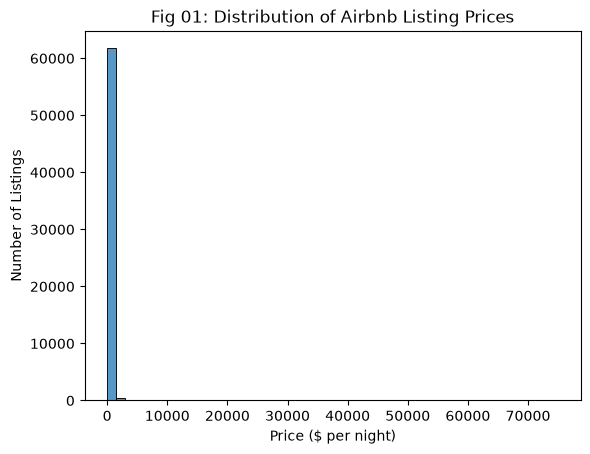

In [25]:
sns.histplot(data=df, x='price', bins=50)
plt.xlabel('Price ($ per night)')
plt.ylabel('Number of Listings')
plt.title('Fig 01: Distribution of Airbnb Listing Prices')
plt.show()

In [26]:
df['price'].describe()

count    62239.000000
mean       262.997803
std        576.265092
min          2.230000
25%        100.000000
50%        180.000000
75%        300.000000
max      75000.000000
Name: price, dtype: float64

The plot and results of `describe()` shows that the distribution of our target variable, `price`, is still heavily right-skewed. The majority of listings are concentrated at relatively low values and there is a small number of listings extending to much larger values. The `mean` of the `price` variable is `~$263` whereas the median is `$180`. This disparity suggests that the `median` of the `price` variable will be more representative of the typical listing price than the `mean`. 

To examine the distribution in better detail, I have limited the plot to pricings of `$1000` or below. This allows the distribution of the majority of listings to be viewed more clearly without the substantially higher priced listings compressing the majority of listings to a small area of the plot. 

The `median` and `mean` are also plotted to show the different measures of central tendency after the larger values have been filtered out. The `mean` is still higher than the `median`, indicating that even following filtering the data is still right-skewed. 

Text(0.5, 1.0, 'Fig 02: Distribution of Airbnb Listing Prices <= $1000')

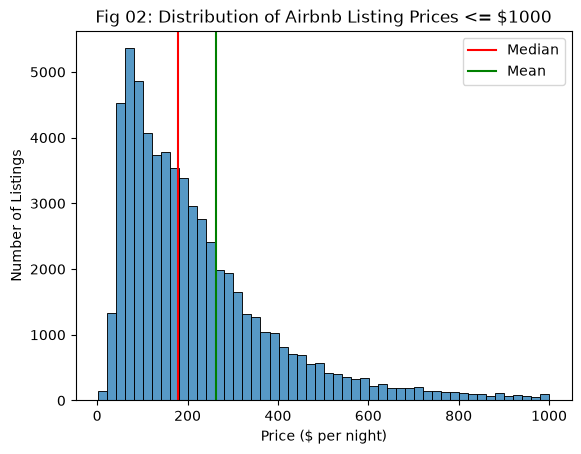

In [27]:
plt.clf()
sns.histplot(data = df[df['price']<= 1000], x='price', bins=50)
plt.axvline(df['price'].median(), color='red', label='Median')
plt.axvline(df['price'].mean(), color='green', label='Mean')
plt.xlabel('Price ($ per night)')
plt.ylabel('Number of Listings')
plt.legend()
plt.title('Fig 02: Distribution of Airbnb Listing Prices <= $1000')

Given that the distribution of the `price` variable is still significantly right-skewed, I will apply a log transformation to reduce the influence of the higher priced listings and assign it to the variable `log_price`. It will also have the befit of approximating a more normal distribution. 

Given that `log_price` is substantially more balanced than the `price` variable, I will use it for the subsequent correlation analyses and modelling while maintaining the `price` variable to interpret the results in real terms.

<Figure size 640x480 with 0 Axes>

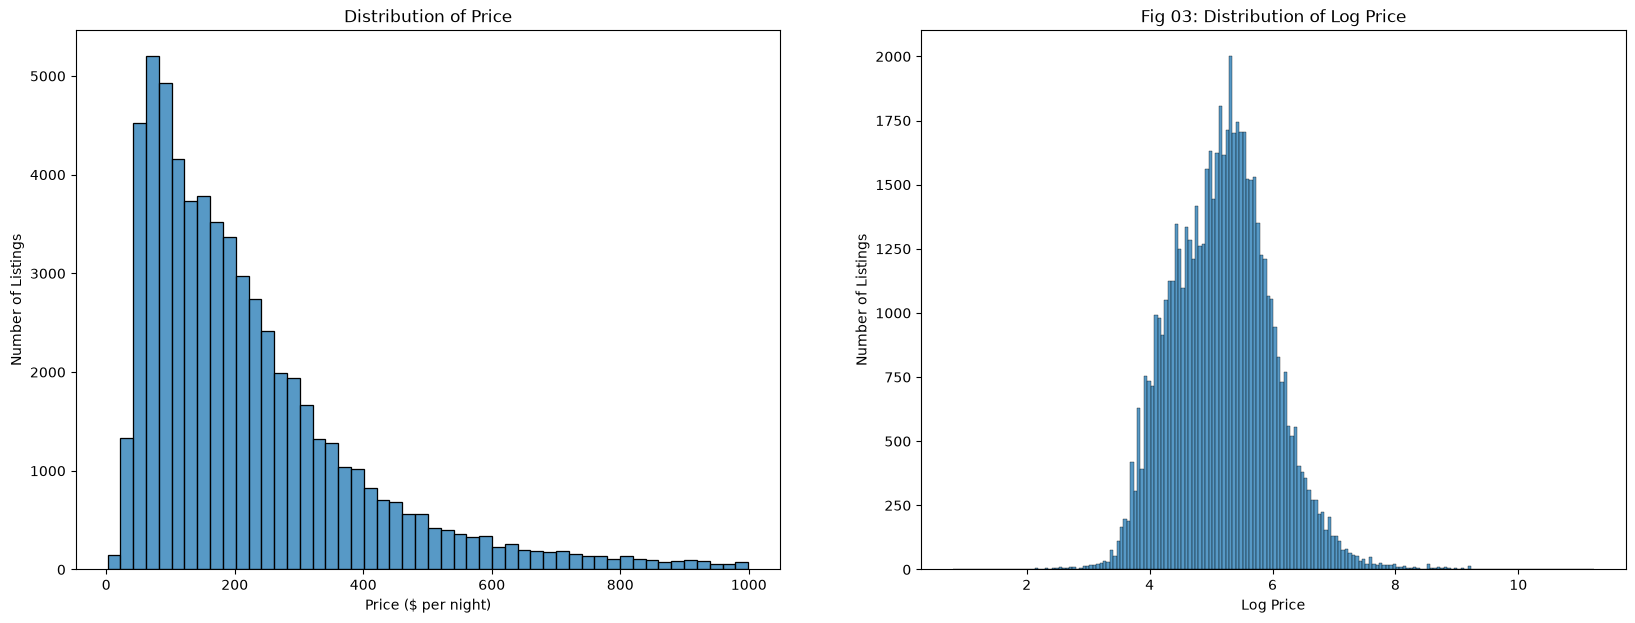

In [28]:
df['log_price'] = np.log(df['price'])
plt.clf()

fig, axes = plt.subplots(1, 2, figsize = (20,7))
sns.histplot(data = df[df['price'] < 1000], x='price', bins=50, ax= axes[0])
axes[0].set_title('Distribution of Price')
axes[0].set_xlabel('Price ($ per night)')
axes[0].set_ylabel('Number of Listings')

sns.histplot(data=df, x='log_price', ax=axes[1])
axes[1].set_title('Fig 03: Distribution of Log Price')
axes[1].set_xlabel('Log Price')
axes[1].set_ylabel('Number of Listings')
plt.show()

### Property Characteristics

I will now investigate the relationship between the different property characteristics and listing prices. This includes `Location`, `property type`, `room type`, `accommodates`, `bedrooms` and `bathrooms`. These features detail the size and physical characteristics of each listing and may help to explain differences in price across properties in London. 

#### Location

Location is likely to have an influence over listing prices, as demand and accommodation costs differ drastically in different parts of London. I will therefore compare the distribution across `neighbourhood_cleansed` and then compare the typical listing price across different neighbourhoods. This will allow me to see if higher pricing is associated with specific areas. 

Text(0, 0.5, 'Neighbourhood')

<Figure size 640x480 with 0 Axes>

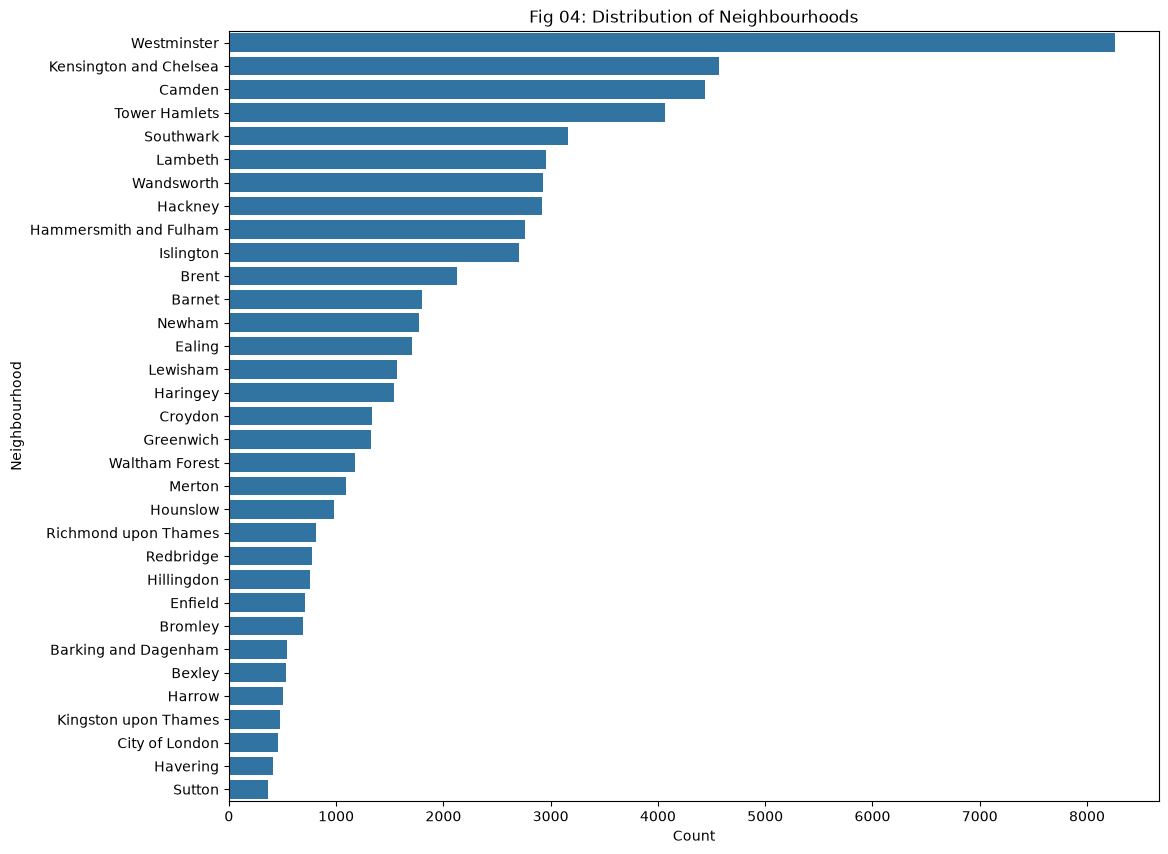

In [29]:
neighbourhood_counts = df['neighbourhood_cleansed'].value_counts()
neighbourhood_counts

plt.clf()
plt.figure(figsize=(12, 10))
sns.barplot(x = neighbourhood_counts.values, y = neighbourhood_counts.index)
plt.title('Fig 04: Distribution of Neighbourhoods')
plt.xlabel('Count')
plt.ylabel('Neighbourhood')

The feature `neighbourhood_cleansed` contains 33 distinct neighbourhoods, with the number of listings varying significantly between them. `Westminster` has the largest number of listings at `8257`, followed by `Kensington and Chelsea` at `4569` listings. Comparatively, several neighbourhoods contain fewer than 500 listings, with `Sutton` having the least at `367`. 

It's important to note the disparity of the number of listings between neighbourhoods, as those with fewer listings could potentially be less representative. 

To investigate whether pricing differs by `neighbourhood_cleansed`, I will yse `groupby()` to calculate the median of `log_price` for each neighbourhood group and compare them using a barchart. Using the median instead of the mean will reduce the influence of any substantially higher priced listings.

<Figure size 640x480 with 0 Axes>

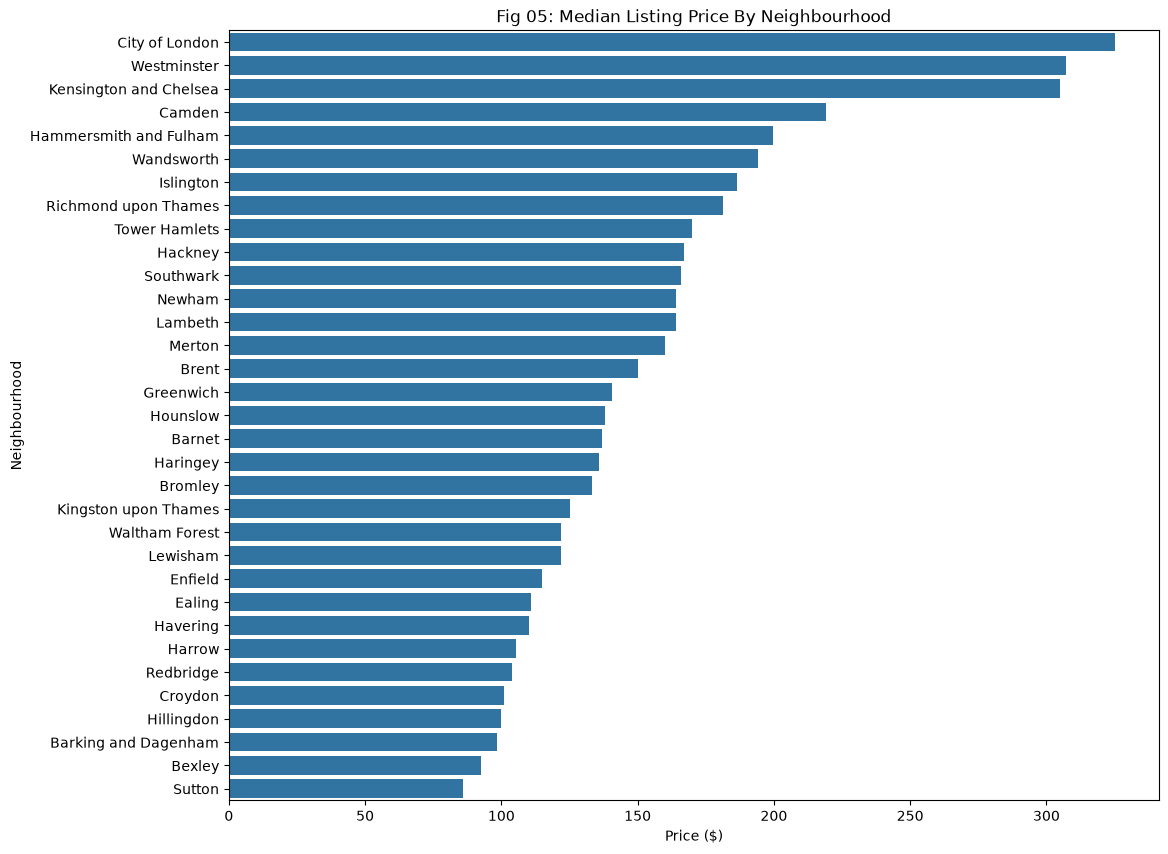

In [30]:
neighbourhood_median = df.groupby('neighbourhood_cleansed')['price'].median().sort_values(ascending=False)

plt.clf()
plt.figure(figsize=(12, 10))
sns.barplot(x = neighbourhood_median.values, y=neighbourhood_median.index)
plt.title('Fig 05: Median Listing Price By Neighbourhood')
plt.xlabel('Price ($)')
plt.ylabel('Neighbourhood')
plt.show()

# print(neighbourhood_median)

The results from `Fig 05` show a clear difference in median pricing across neighbourhoods, with central areas having higher pricings than areas further from the centre. The median price ranges from a high of `$307` a night in Westminster to a low of `$85` a night in Sutton. This suggests that there is a strong association between location and listing price, though it's important to note that a difference in the number of listings between areas could have an influence on their relative medians. 


Given that the number of listings differs greatly depending on location, I will next investigate whether there is a relationship between the number of listings and an area's median price. A strong relationship could suggest that neighbourhoods iwth fewer listings produce different median prices, which would be important when interpreting the previous results from `fig 05`. To assess this relationship I will use the `Spearmanr()` function from `scipy.stats` and use `regplot()` to visualise the relationship.

<Figure size 640x480 with 0 Axes>

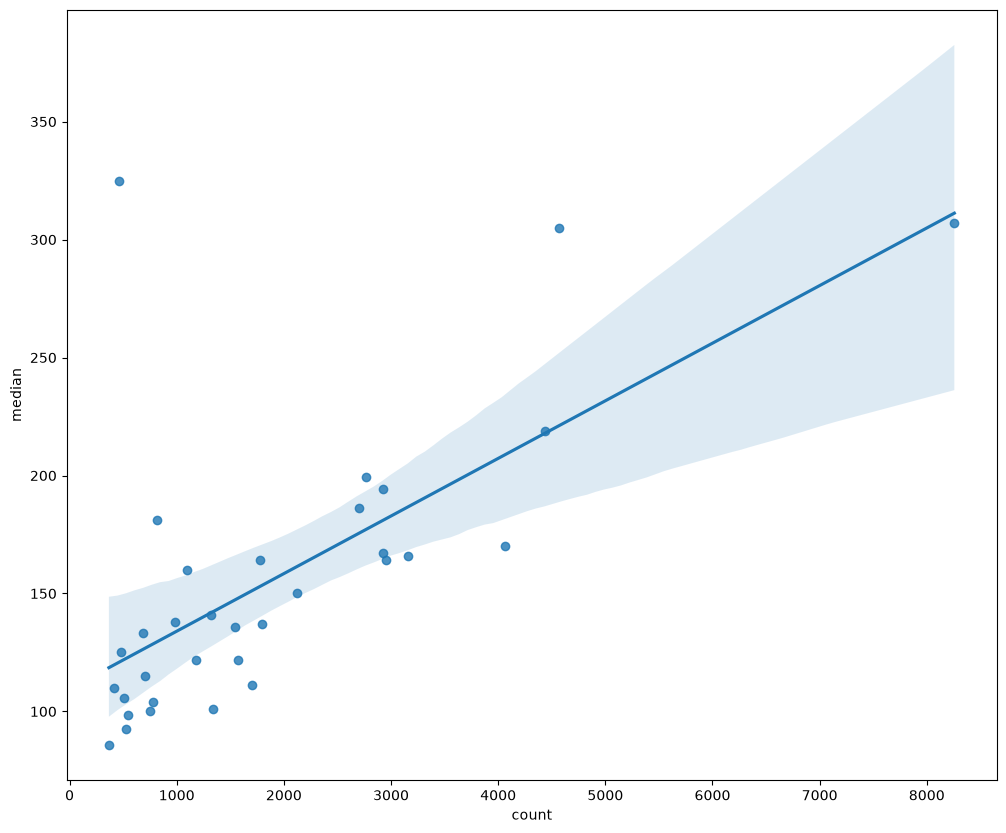

                        count   median
neighbourhood_cleansed                
Westminster              8257  307.000
Kensington and Chelsea   4569  305.000
Camden                   4440  219.000
Tower Hamlets            4068  170.000
Southwark                3163  166.000
Lambeth                  2954  164.165
Wandsworth               2925  194.290
Hackney                  2922  167.190
Hammersmith and Fulham   2763  199.500
Islington                2704  186.420
Brent                    2125  150.000
Barnet                   1800  137.000
Newham                   1776  164.250
Ealing                   1707  111.000
Lewisham                 1570  121.800
Haringey                 1542  136.000
Croydon                  1336  100.940
Greenwich                1323  140.670
Waltham Forest           1180  122.000
Merton                   1093  160.000
Hounslow                  981  138.000
Richmond upon Thames      817  181.170
Redbridge                 779  104.000
Hillingdon               

In [31]:
neighbourhood_summary = df.groupby('neighbourhood_cleansed')['price'].agg(['count', 'median'])

plt.clf()
plt.figure(figsize=(12, 10))
sns.regplot(data=neighbourhood_summary, x = 'count', y = 'median')
plt.show()

print(neighbourhood_summary.sort_values(by='count', ascending=False))
rho, p = spearmanr(neighbourhood_summary['count'], neighbourhood_summary['median'])

print("The rho is {} \nThe P value is {}".format(rho, p))

The results show a moderately strong positive correlation between the number of listings in a neighbourhood and the median price of listings with a correlation of `p = 0.67`. This relationship has a p value of `0.0000165`, indicating that there is statistical significance between the counts of listings and the median price of each neighbourhood group and that neighbourhoods with more listings tend to have a higher median price. \
It's worth noting however that this relationship is likely influenced by other confounding variables such as the desirability of a location, its access to amenities or its distance to the centre of London, so this relationship alone does not prove that a higher density of listings leads to higher prices. 

#### Property Type

`Property type` is another characteristic that could have an association with a listing's price, as different types of properties offer different levels of privacy, size and amenities. I will first plot the results from calling `value_counts()` to check the distribution of property type and then compare the median listing's prices to identify any differences between categories. 

<Figure size 640x480 with 0 Axes>

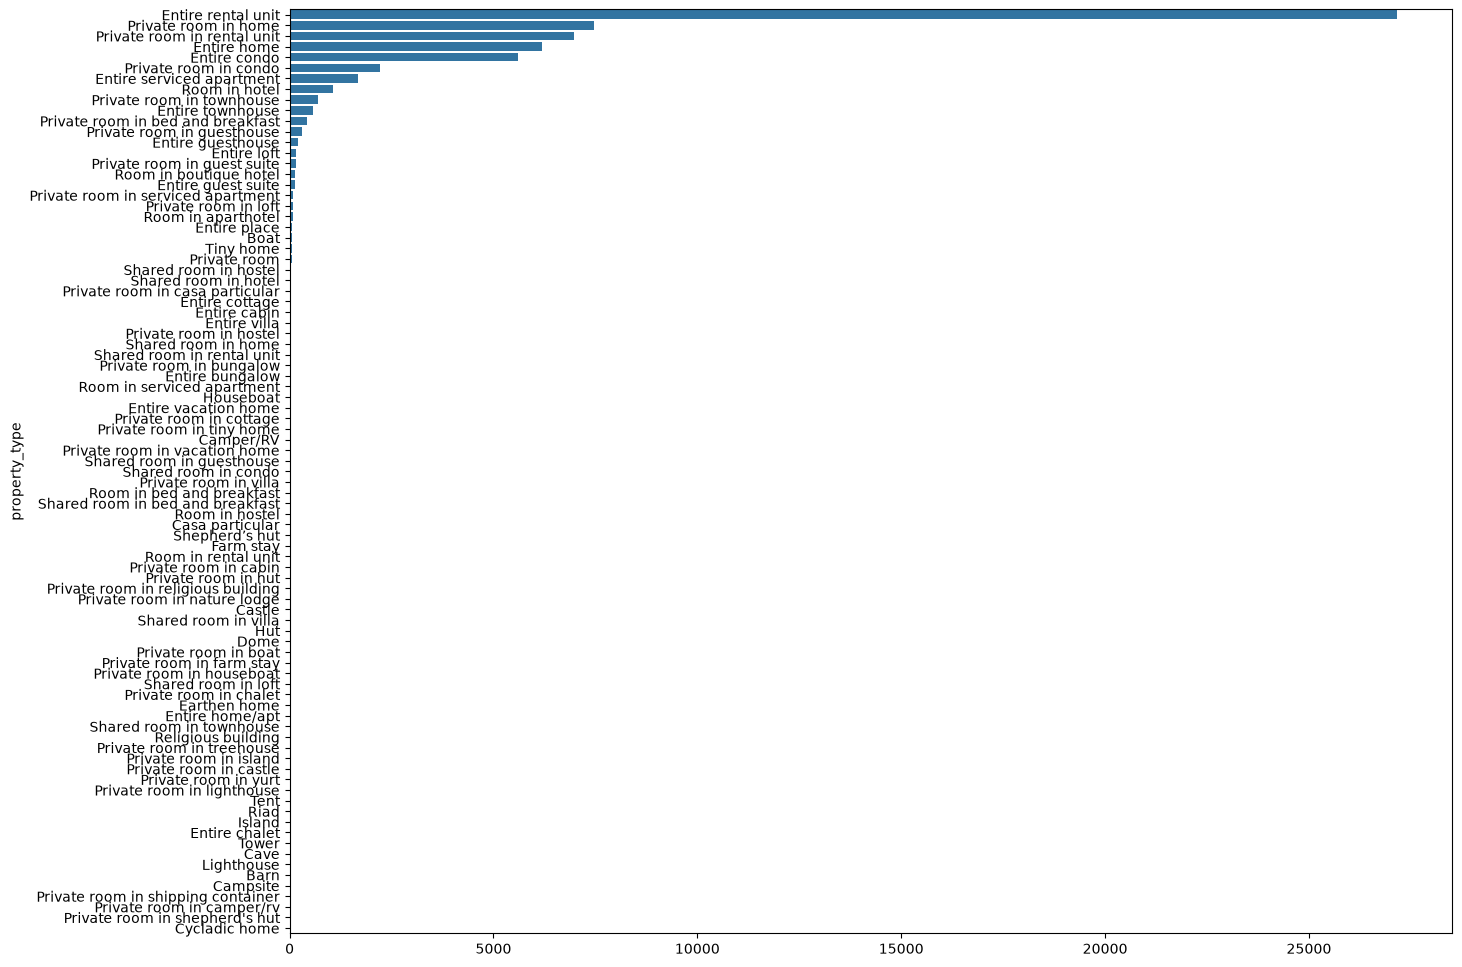

In [32]:
type_counts = df['property_type'].value_counts()
plt.clf()
plt.figure(figsize=(15, 12))
sns.barplot(x=type_counts.values, y = type_counts.index)
plt.show()

The distribution of `property_type` shows that the dataset is heavily concentrated to a select few property types. `Entire rental unit` has the most listings by a large margin at `27153` entries, followed by `Private room in home` at `7461` listings and `Private room in rental unit` as `6975` listings. Comparatively, entries such as `Private room in shipping container` and `Private room in camper/rv` have only a single listing. I will therefore focus the analysis of median prices based on `property_type` to listings with a sufficient number of entries (>=100) in order to give more reliable estimates. 

In [33]:
property_median = df.groupby('property_type')['price'].agg(['count', 'median']).query('count >= 100').sort_values(by='median', ascending=False)
property_median

,count,median
property_type,,
Entire townhouse,584,405.355
Entire home,6178,310.000
Entire serviced apartment,1679,270.000
Entire rental unit,27153,229.000
Entire condo,5595,220.000
Entire loft,166,188.500
Room in boutique hotel,142,184.035
Room in hotel,1060,157.000
Entire guesthouse,207,122.670


<Axes: xlabel='median', ylabel='property_type'>

<Figure size 640x480 with 0 Axes>

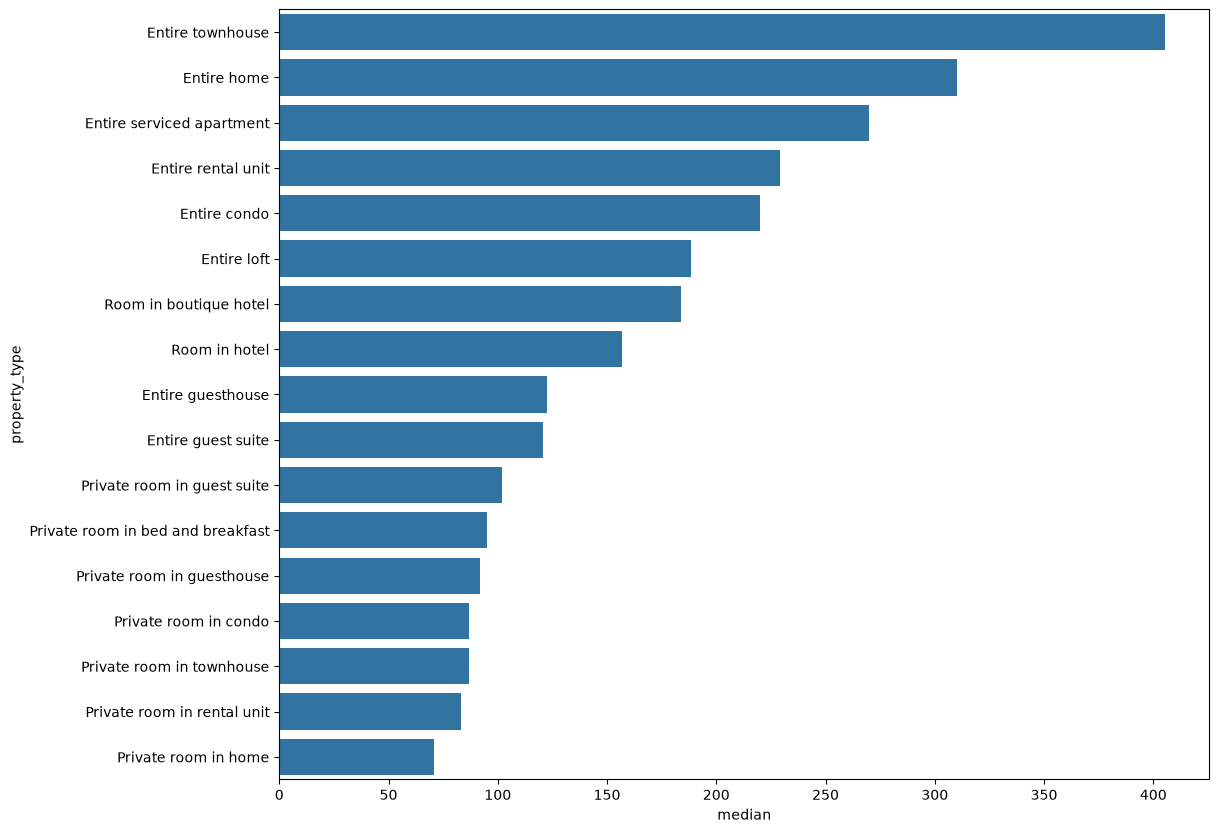

In [34]:
plt.clf()
plt.figure(figsize=(12, 10))
sns.barplot(data = property_median, x = 'median', y = property_median.index)

The results show large differences in average prices between different property types. `Entire townhouse` has the largest median price at `~$405` followed by `Entire home` at `$310`. Comparatively, listings that are private rooms have much lower averages, with `Private room in home` and `Private room in rental unit` having a median of `$71` and `$83` respectively. Overall, entire properties have a significantly higher average price than private room listings, suggesting that the property type and the level of privacy/amenities that they offer are heavily associated with a listing's price. 

In [35]:
room_type_counts = df['room_type'].value_counts(ascending=False)
room_type_counts

room_type
Entire home/apt    42122
Private room       19826
Shared room          183
Hotel room           108
Name: count, dtype: int64

In [36]:
room_type_median = df.groupby('room_type')['price'].agg(['count', 'median']).sort_values(by='median', ascending=False)
room_type_median

,count,median
room_type,,
Entire home/apt,42122,239.500
Hotel room,108,156.000
Private room,19826,82.265
Shared room,183,44.000


<Figure size 640x480 with 0 Axes>

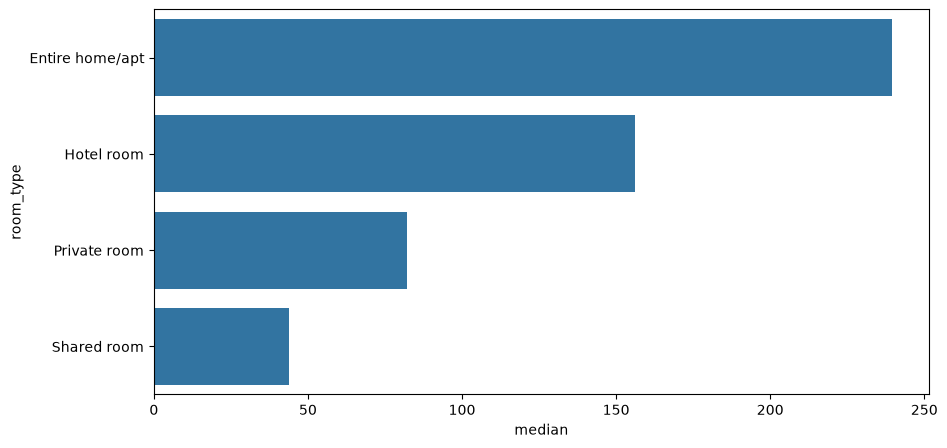

In [37]:
plt.clf()
plt.figure(figsize=(10, 5))
sns.barplot(data=room_type_median, x = 'median', y = room_type_median.index)
plt.show()

#### Accommodates

The `accommodates` feature tells us the maximum number of guests that each listing accommodates, and therefore provides a measure of the size of a property and its capacity. Larger properties may be associated with higher prices, so I will again begin by examining the distribution of `accommodates` and then investigate where there is an association with median prices. 

In [38]:
accommodates_count = df['accommodates'].value_counts().sort_index()
accommodates_count

accommodates
1      6529
2     22663
3      4873
4     12819
5      3890
6      6096
7      1393
8      2105
9       455
10      713
11      128
12      239
13       62
14       95
15       37
16      142
Name: count, dtype: int64

<Figure size 640x480 with 0 Axes>

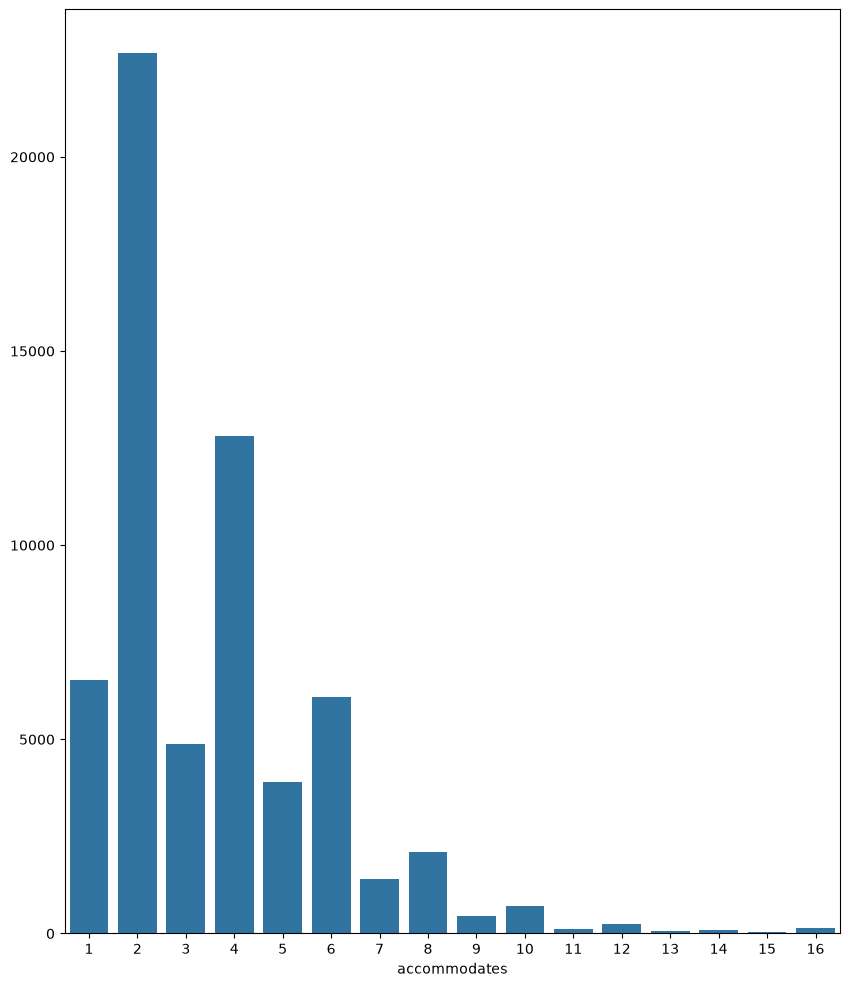

In [39]:
plt.clf()
plt.figure(figsize=(10, 12))
sns.barplot(x = accommodates_count.index, y = accommodates_count.values)
plt.show()

The distribution of `accommodates` shows that the available capacity of the listings are mostly concentrated around smaller groups. Properties listed for 2 people, ie couples, are most common at a count of `22663` followed by those accommodating 4 guests at `12819` and 1 guest at `6529`. The number of listings generally decrease as the capacity increases, with the maximum capacity of `16` having a count of only `142` in comparison. I will therefore investigate whether listing capacity is associated with differences in the median price.

In [40]:
accommodates_median = df.groupby('accommodates')['price'].agg(['count', 'median']).sort_index()
accommodates_median

,count,median
accommodates,,
1,6529,66.500
2,22663,119.330
3,4873,169.000
4,12819,238.330
5,3890,264.715
6,6096,336.000
7,1393,344.500
8,2105,420.000
9,455,362.000


<Figure size 640x480 with 0 Axes>

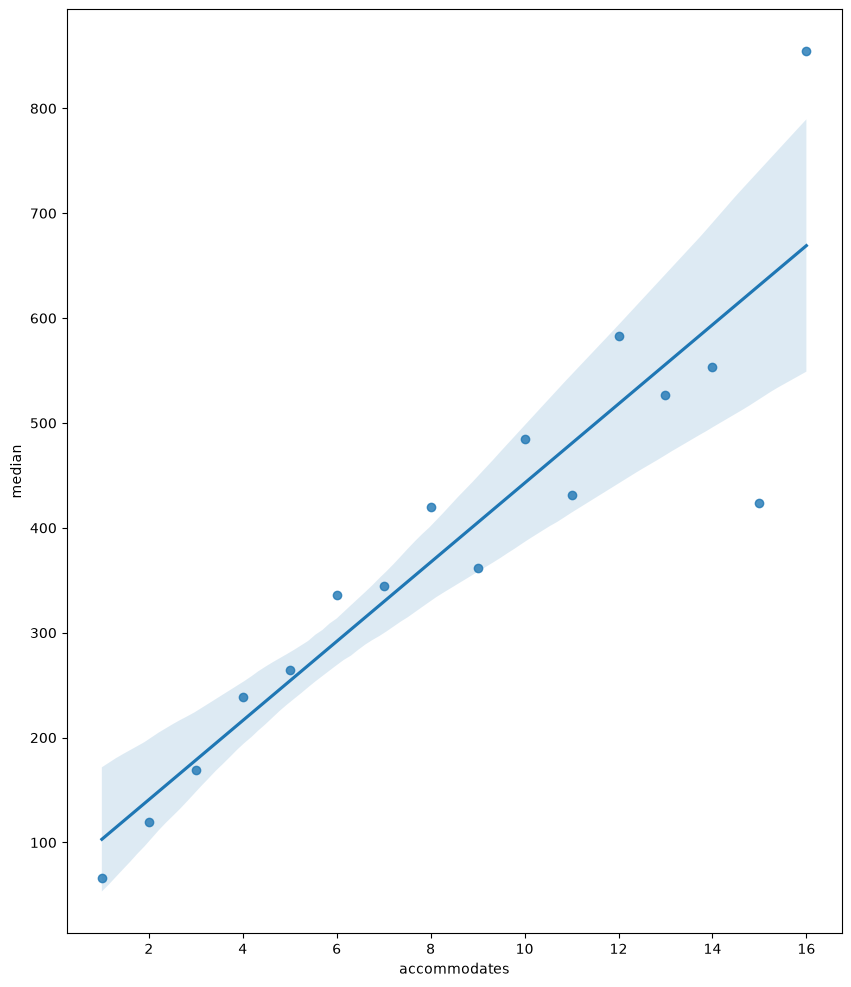

The rho is 0.9411764705882352, the p value is 5.588937633072706e-08


In [41]:
plt.clf()
plt.figure(figsize=(10, 12))
sns.regplot(data = accommodates_median, x = accommodates_median.index, y = 'median')
plt.show()

rho, p = spearmanr(accommodates_median.index, accommodates_median['median'])
print("The rho is {}, the p value is {}".format(rho, p))

As one might expect, the results show a very strong correlation between the capacity of a listing and its median price, with a spearman correlation of `ρ = 0.94` and a p value of `5.588937633072706e-08`, showing statistical significance. This indicates that listings with a higher capacity are heavily associated with an increase in listing price.

#### Bedrooms

The `bedrooms` feature is similar to `accommodates`, but gives a slightly more specific measure of property size given that some bedrooms host singular guests. As properties with more bedrooms may be able to accommodate larger groups and offer more space, this feature could also be associated with higher listing prices. I will again investigate the distribution of `bedrooms` before investigating its relationship with `price`. 

In [42]:
bedrooms_counts = df['bedrooms'].value_counts().sort_index()


<Figure size 640x480 with 0 Axes>

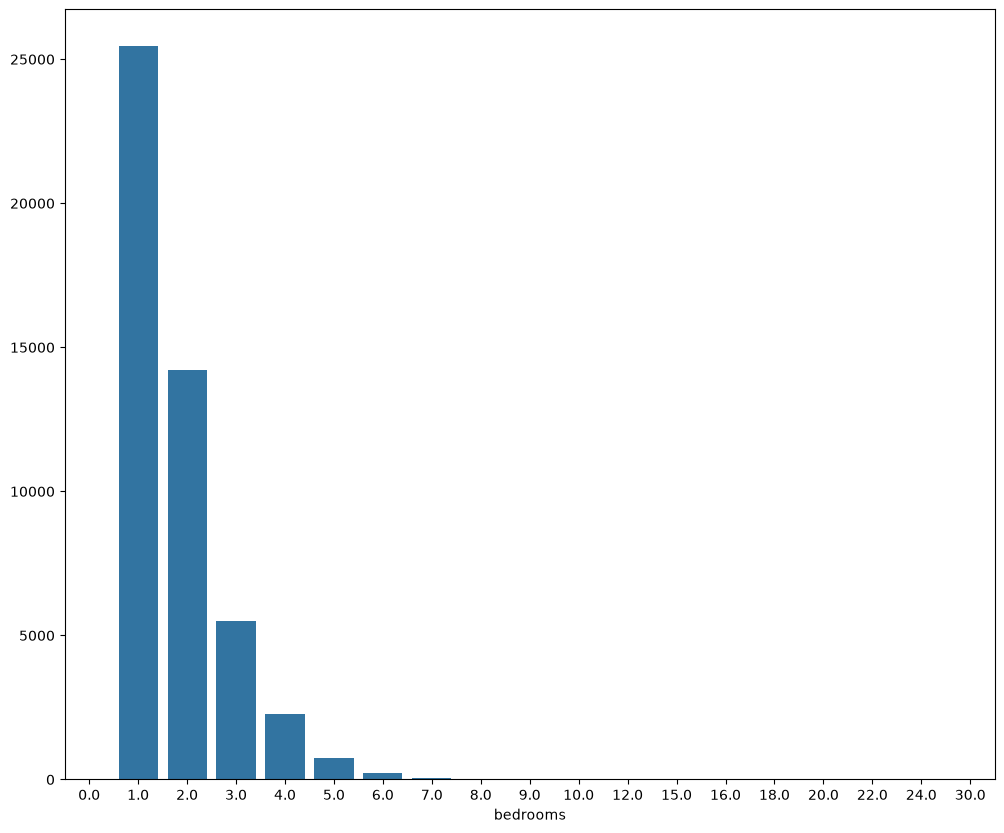

In [43]:
plt.clf()
plt.figure(figsize=(12, 10))
sns.barplot(x = bedrooms_counts.index, y = bedrooms_counts.values)
plt.show()

The distribution of `bedrooms` has a heavy concentration around the lower values, with each addition of added bedrooms seeing a substantial drop in the number of listings. Listings with only 1 bedroom dominate the dataset at a count of `25454`, followed by 2 bedrooms at `14215` and 3 bedrooms at `5486`. Beyond this point, the number of listings decreases even further, with only a few listings with a bedroom count of `>=6` being present in the dataset. I will now examine whether the number of bedrooms is associated with an increase in listing price.

In [44]:
bedrooms_median = df.groupby('bedrooms')['price'].agg(['count', 'median']).sort_index()
bedrooms_median

,count,median
bedrooms,,
0.0,8,114.930
1.0,25454,156.000
2.0,14215,275.000
3.0,5486,350.000
4.0,2266,402.625
5.0,743,486.780
6.0,211,553.500
7.0,56,840.000
8.0,34,876.000


<Figure size 640x480 with 0 Axes>

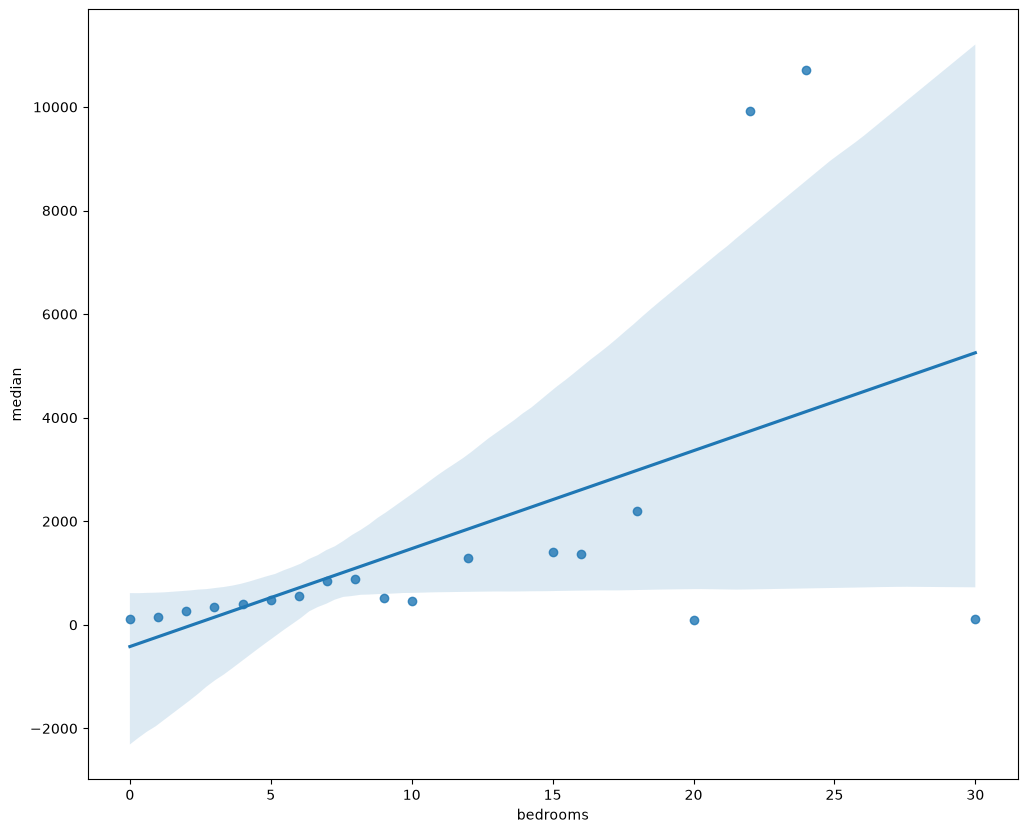

The rho is 0.45614035087719296, the p value is 0.049655395879569776


In [45]:
plt.clf()
plt.figure(figsize = (12, 10))
sns.regplot(data = bedrooms_median, x = bedrooms_median.index, y = 'median')
plt.show()
rho, p = spearmanr(bedrooms_median.index, bedrooms_median['median'])
print("The rho is {}, the p value is {}".format(rho, p))

The results show a clear association between the number of bedrooms and the listing price across the more common property sizes. The median increases from `$156` for singular bedrooms to `$275` for 2 bedrooms, then increases again to `$350` for 3 bedrooms properties and `$403` for properties with 4 bedrooms. For the most part, this trend continues across listings as the number of bedrooms increases, though it's important to note that properties exceeding 6 bedrooms have substantially less listings so do not produce reliable results. Interestingly, there's a notable decrease in listing price at `20` bedrooms and `30` bedrooms, suggesting that there may be an inaccuracy with the data entry. \
The spearman rank shows that across the entire dataset there is a `ρ` of `0.456` and a `p value` of `~0.0497`, showing there is a moderate correlation that does only just has statistical significance. However, the relatively small number of entries for properties exceeding 6 bedrooms could have an impact on the analysis, so I will filter the listings to a property count of `>=50` and conduct the spearman's rank again. 

In [46]:
bedrooms_median_cutoff = df.groupby('bedrooms')['price'].agg(['count', 'median']).query('count >=50').sort_index()
bedrooms_median_cutoff


,count,median
bedrooms,,
1.0,25454,156.000
2.0,14215,275.000
3.0,5486,350.000
4.0,2266,402.625
5.0,743,486.780
6.0,211,553.500
7.0,56,840.000


<Figure size 640x480 with 0 Axes>

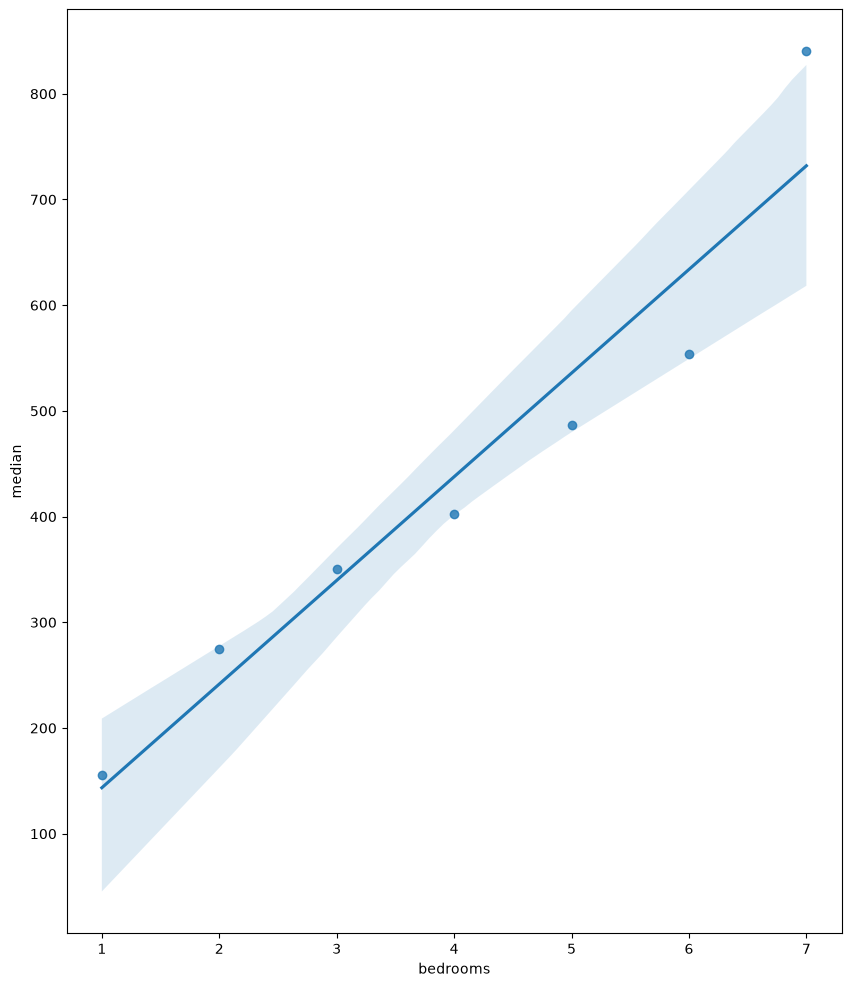

The rho is 1.0, the p value is 0.0


In [47]:
plt.clf()
plt.figure(figsize=(10, 12))
sns.regplot(data=bedrooms_median_cutoff, x = bedrooms_median_cutoff.index, y = 'median')
plt.show()

rho, p = spearmanr(bedrooms_median_cutoff.index, bedrooms_median_cutoff['median'])
print("The rho is {}, the p value is {}".format(rho, p))

After filtering to bedrooms with a count of more than 50, the results show a consistent positive correlation between the number of bedrooms and the median listing price. The median increases from `$156`for listings with a single bedroom to `$840` for listings with 7 bedrooms.
The spearman's rank shows a `ρ of 1.0` and a `p value of ≈0.0`. This perfect looking correlation occurs because the median price increase monotonically across all 7 bedroom categories. \
This shouldn't however be interpreted as bedroom count being a perfect predictor of listing price as the analysis is based on only 7 groups, but the analysis does show strong descriptive evidence that larger properties tend to have higher listing prices. 

#### Bathrooms

`Bathrooms` is yet another feature that are associated with property size and capacity, so may also be associated with listing price. Properties that have more bathrooms are likely to cater to larger groups and offer different levels of luxury and convenience. I will again begin by examining the distribution of the `bathrooms` variable before investigating whether the number of bathrooms is associated with a higher median price. 

<Figure size 640x480 with 0 Axes>

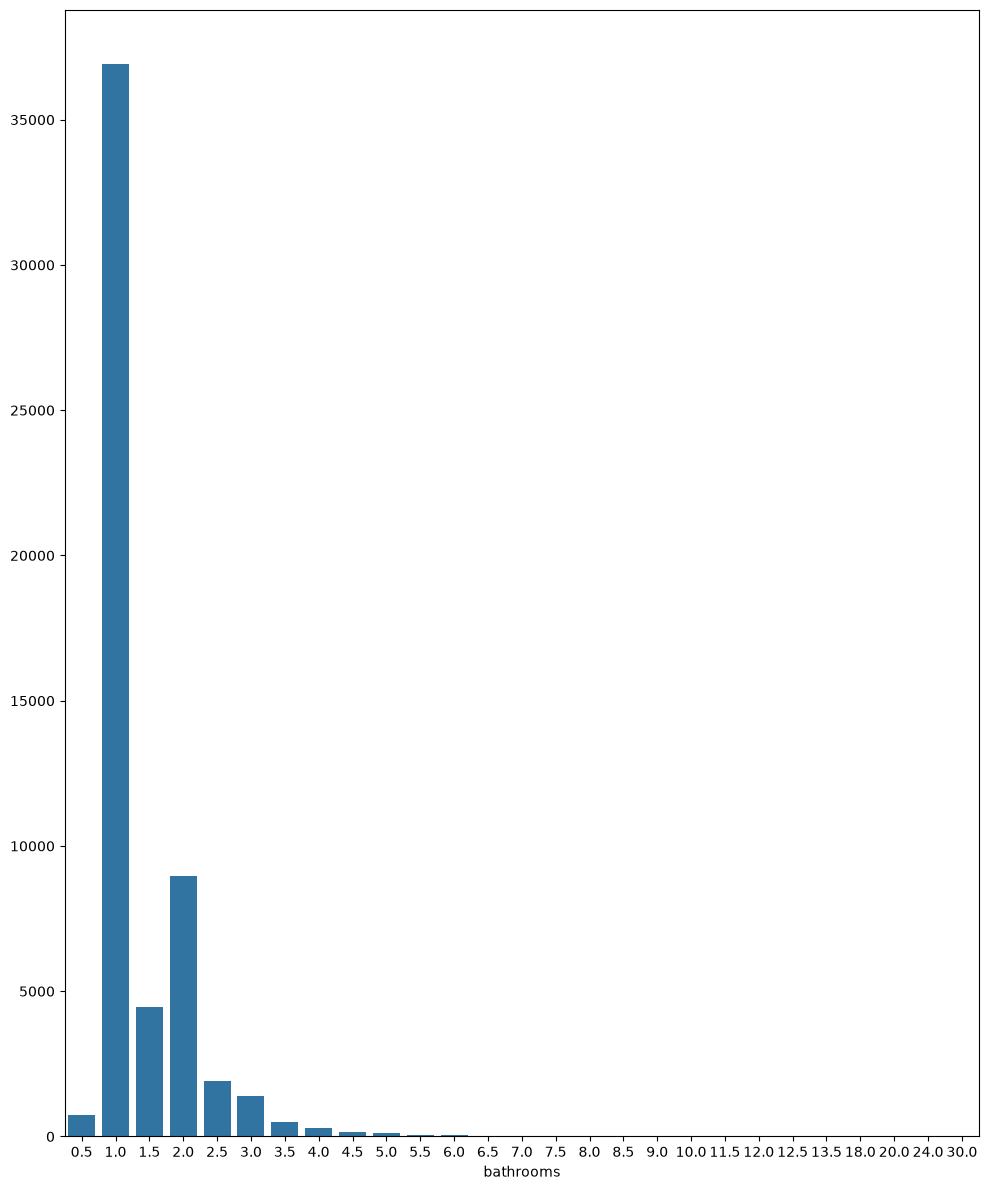

In [48]:
bathrooms_counts = df['bathrooms'].value_counts().sort_index()
plt.clf()
plt.figure(figsize=(10, 12))
sns.barplot(x = bathrooms_counts.index, y = bathrooms_counts.values)
plt.tight_layout()

As expected, the number of bathrooms is once again heavily concentrated around properties with fewer bathrooms. Properties with a singular bathroom dominate the dataset with a count of `36930`, properties with 2 bathrooms are the second most common at `8967`, followed by properties with with 1.5 bathrooms at `4462`. The number of properties decreases substantially as the number of bathrooms increases, with relatively few properties having more than 4 bathrooms. I will now continue to examine whether there is an association between the number of bathrooms that a property has and listing price. 

GIven that bathrooms counts with a small number of listings are likely to distort results, I decided to filter the `bathrooms` variable to values with a count of `>=50`

In [49]:
bathrooms_median_cutoff = (df.groupby('bathrooms')['price'].agg(['count', 'median']).query('count >= 50').sort_index())

bathrooms_median_cutoff

,count,median
bathrooms,,
0.5,755,77.500
1.0,36930,158.000
1.5,4462,148.585
2.0,8967,319.200
2.5,1908,374.750
3.0,1397,453.330
3.5,511,580.000
4.0,281,697.500
4.5,141,804.000


<Figure size 640x480 with 0 Axes>

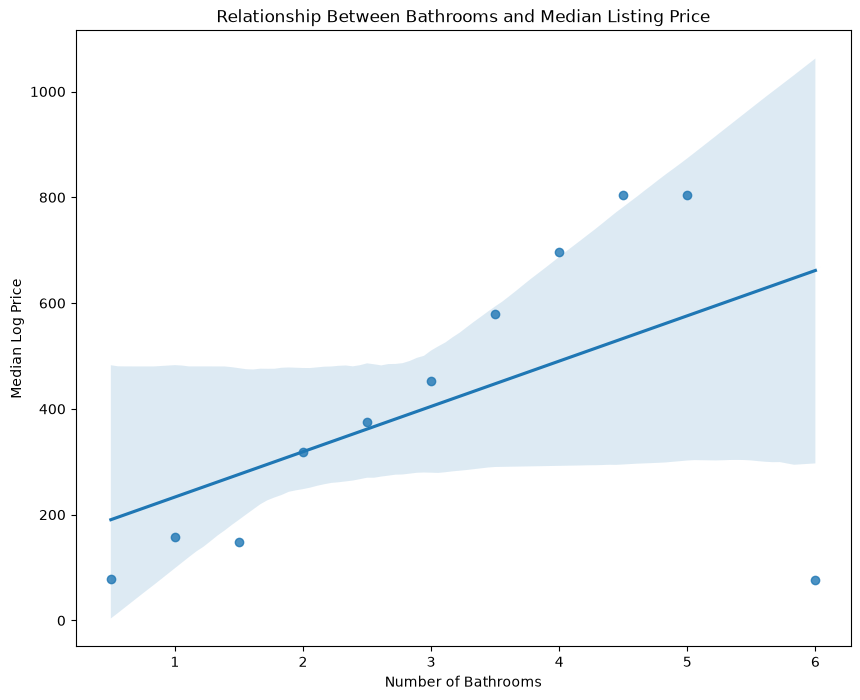

The rho is 0.4909090909090909, the p value is 0.12520440713849545


In [50]:
plt.clf()
plt.figure(figsize=(10, 8))

sns.regplot(data = bathrooms_median_cutoff, x = bathrooms_median_cutoff.index, y = 'median')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Median Log Price')
plt.title('Relationship Between Bathrooms and Median Listing Price')
plt.show()

rho, p = spearmanr(bathrooms_median_cutoff.index, bathrooms_median_cutoff['median'])

print("The rho is {}, the p value is {}".format(rho, p))

The results show a generally positive association between bathroom count and median price across the more common property sizes. Median price increases from `$158` for properties with `1` bathroom to `$319` for `2` bathrooms, `$453` for `3` bathrooms and approximately `$805` for `5` bathrooms.
However, there is a substantial drop in median price to only `$76.5` for properties with `6` bathrooms. This unexpected result is suspicious and bringing the correlation down, so I will investigate these listings further.

In [51]:
df[df['bathrooms'] == 6][['bathrooms', 'price', 'property_type', 'room_type', 'accommodates']].sort_values('price')

,bathrooms,price,property_type,room_type,accommodates
75217,6.0,39.00,Private room in rental unit,Private room,3
77803,6.0,39.00,Private room in rental unit,Private room,2
75304,6.0,40.00,Private room in rental unit,Private room,6
80467,6.0,43.00,Private room in rental unit,Private room,2
80466,6.0,45.00,Private room in rental unit,Private room,2
86845,6.0,45.00,Private room in rental unit,Private room,1
84699,6.0,45.00,Private room in rental unit,Private room,6
80465,6.0,45.00,Private room in rental unit,Private room,2
75218,6.0,49.00,Private room in rental unit,Private room,4
84658,6.0,50.00,Private room in rental unit,Private room,6


Investigating the 6-bathroom listings explains the unexpected drop in median price. The category contains a mixture of substantially different listing types, with many low-priced private-room listings alongside entire homes and townhouses with considerably higher prices. For example, several private-room listings are priced below $100, while entire properties in the same category range into the thousands of dollars per night. This suggests that the unusually low median is largely influenced by the composition of the listings within this category rather than the number of bathrooms itself. I will therefore retain these observations rather than treating the 6-bathroom category as an error, but interpret the relationship between bathroom count and price with caution.

### Host Characteristics

Now that I have analysed the relationship between `property characteristics` and `price`, I will next investigate whether characteristics of the host are also associated with our target variable, `price`. In particular, I will focus on the features `host_is_superhost` and `hosts_time_as_host_years` to determine whether host status or experience is associated with listing prices. 

#### Superhost Status

The first host characteristic I will investigate is the variable `host_is_superhost`, which is a binary variable saying the status of a host. Hosts with the superhost status may differ from standard hosts in terms of experience and service quality, which could be associated with higher listing prices. I will begin again by viewing the distribution of superhosts and I will then compare the summary statistics between the two groups. 

In [52]:
superhost_counts = df['host_is_superhost'].value_counts()
superhost_counts

host_is_superhost
f    47068
t    15105
Name: count, dtype: int64

The spread shows that the majority of the dataset consists of regular hosts, with a count of `47068`. In comparison, those with superhost status have a count of `15105`. Even though there are significantly less superhosts, the number of observations is still large enough for both groups to compare their listing prices. 

I will begin investigating the association between `host_is_superhost` and `price` by creating boxplots to compare the distribution of `log_price` for each host status. I have opted to use `log_price` instead of `price` as there are outliers in the data that would compress the boxplots and make them less interpretable if I were to use `price`. This will allow me to better compare the median and spread of each group while also identifying any substantial differences in the upper and lower percentiles. 

<Axes: xlabel='host_is_superhost', ylabel='log_price'>

<Figure size 640x480 with 0 Axes>

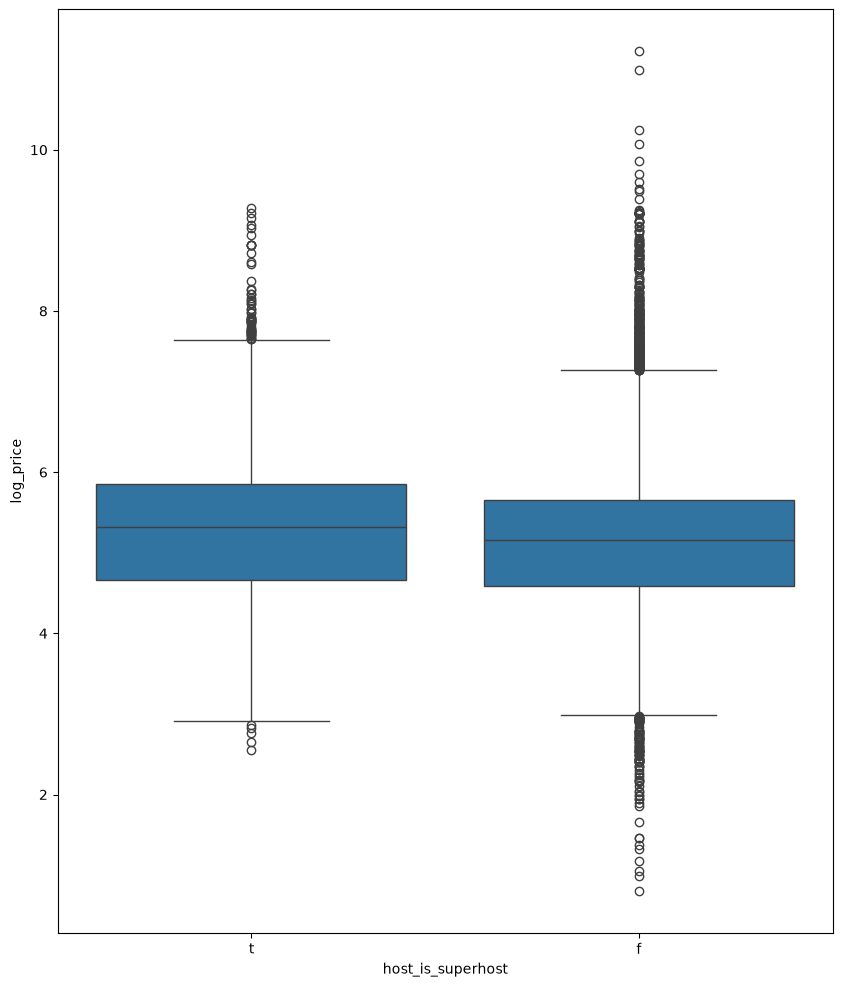

In [53]:
plt.clf()
plt.figure(figsize=(10, 12))
sns.boxplot(data=df, x='host_is_superhost', y='log_price')

In [54]:
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]

superhost_percentiles = (
    df.groupby('host_is_superhost')['price']
      .quantile(percentiles)
      .unstack()
)

superhost_percentiles.columns = [
    '1%', '5%', '10%', '25% (Q1)', '50% (Median)',
    '75% (Q3)', '90%', '95%', '99%', '99.5%', '99.9%'
]

superhost_percentiles

,1%,5%,10%,25% (Q1),50% (Median),75% (Q3),90%,95%,99%,99.5%,99.9%
host_is_superhost,,,,,,,,,,,
f,34.5134,50.21,63.0,98.0,174.5,287.0,460.0,651.0,1360.0000,2099.88945,6398.5930
t,37.0000,52.00,65.0,105.5,203.7,348.0,550.0,733.5,1402.2368,1745.44000,3849.1284


The results show that hosts with the `superhost` status generally have higher prices for their listings across the main body of the distribution. The median for `superhosts` is `$203.70` compared to `$174.5` for `non-superhosts`, while the middle 50% of listings range from `$105.50` to `203.70` for `superhosts` compared with `$98.00` to `$287.00` for `non-superhosts`. The trend of `superhosts` having higher priced listings continues up to the `99th percentile`. However, at the `99.5th percentile` and upwards, those with `non-superhost` status have substantially higher listing prices, evidencing that the outliers of the dataset belong primarily to the `non-superhost` group. These results tell us that `host_is_superhost` is associated with higher listing prices for the vast majority of the dataset, while the `non-superhost` group contains more extreme priced listings. 

While the descriptive statistics suggest that there is an association between `host_is_superhost` and `log_price`, there is a possibility that this could just be a result of random variation in the data. I will therefore conduct a hypothesis test to determine whether there is statistical evidence of the difference in `log_price`. I will use `Welch's t-test` by setting `equal_val=False`, as this does not assume that the two groups have equal variances. 

In [55]:
superhosts = df[df['host_is_superhost']=='t']['log_price']
not_superhosts = df[df['host_is_superhost']=='f']['log_price']

test_result = ttest_ind(superhosts, not_superhosts, equal_var = False)
test_result

TtestResult(statistic=np.float64(16.162540155082088), pvalue=np.float64(1.83579270496577e-58), df=np.float64(24970.446210776277))

The t-test produced a test statistic of `16.16` and a p value of `1.84 × 10⁻⁵⁸`. This is substantially below for threshold of significance (0.05), indicating there is statistical evidence that the mean `log_price` differs between `superhost` and `non-superhost`. This is supported by the above boxplots, where `superhost` listings usually have higher prices. However, it's important to note that this test only identifies a relationship and does not define a causal relationship as there are many potential confounders such as location or property characteristics that may also influence price. 

#### Host Time (Years)

The variable `host_time_as_host_years` measures the length of time that each host has been active on Airbnb and therefore indicates the level of experience each host has. Hosts with more experience may be associated with different listing prices as they could have different pricing strategies or operate different property types, so I will investigate whether there is a relationship between `host_time_as_host_years` and `price`. I will once again begin by viewing the distribution of `host_time_as_host_years` and follow up by comparing the median of the target variable `price` across different levels of host experience. 

<Figure size 640x480 with 0 Axes>

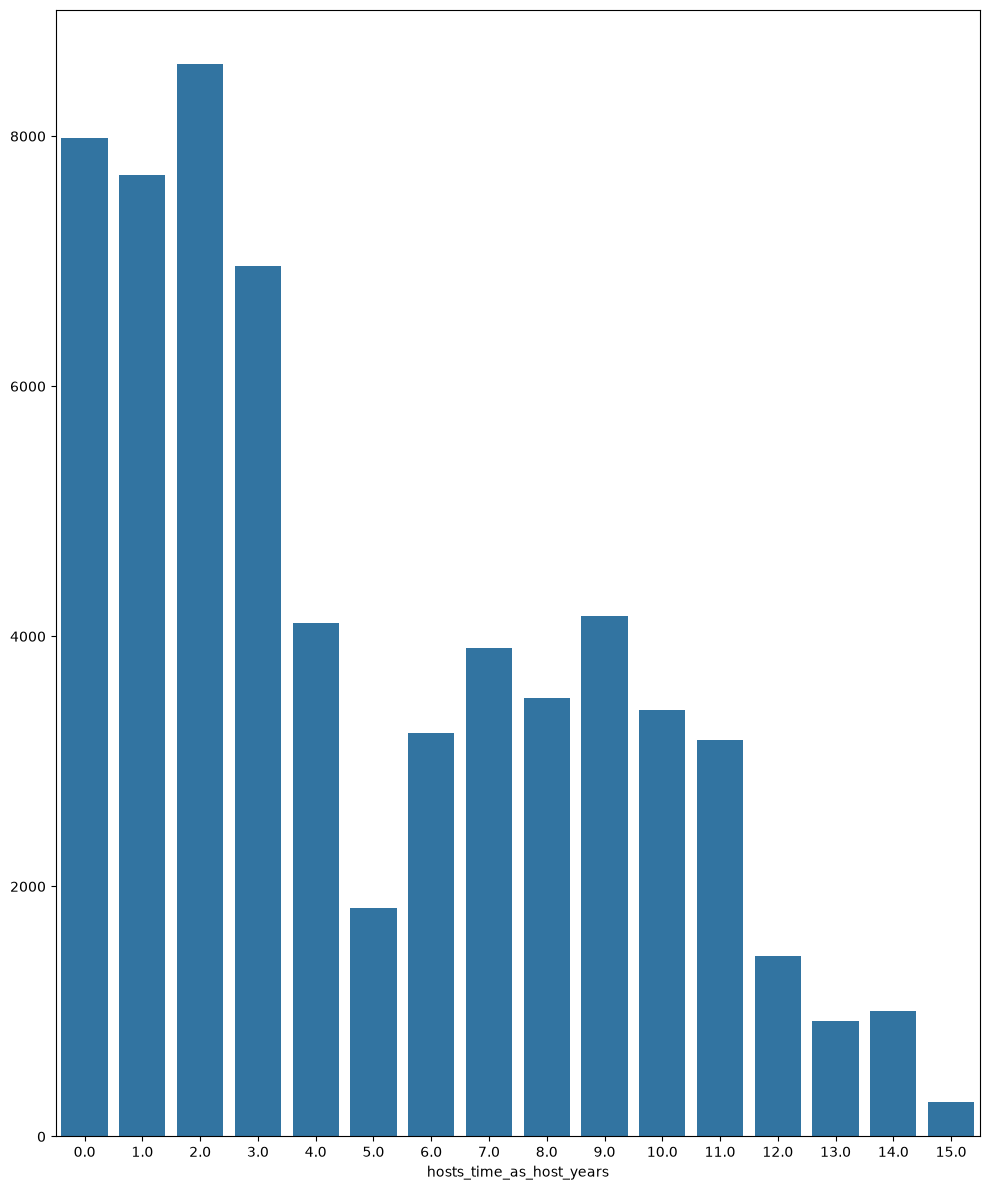

In [56]:
hosts_times_as_years = df['hosts_time_as_host_years'].value_counts().sort_index()
plt.clf()
plt.figure(figsize=(10, 12))
sns.barplot(x = hosts_times_as_years.index, y = hosts_times_as_years.values)
plt.tight_layout()
plt.show()

In [57]:
hosts_times_as_years.sort_values()

hosts_time_as_host_years
15.0     272
13.0     922
14.0    1006
12.0    1447
5.0     1828
11.0    3173
6.0     3226
10.0    3408
8.0     3507
7.0     3908
4.0     4104
9.0     4160
3.0     6959
1.0     7691
0.0     7982
2.0     8580
Name: count, dtype: int64

The distribution shows that there is a wide variety of host experience across the dataset, with observations starting at `0` years spanning all of the way up to `15` years. The data is largely concentrated around newer hosts, with `2 years` having a count of `8580`, `0 years` having a count of `7982` and `1 year` having a count of `7691`. The number of years generally decreases after 3 years, with `15 years` having the lowest count at `272`. This provides enough evidence to investigate whether `hosts_time_as_host_years` is associated with listing price. 

<Figure size 640x480 with 0 Axes>

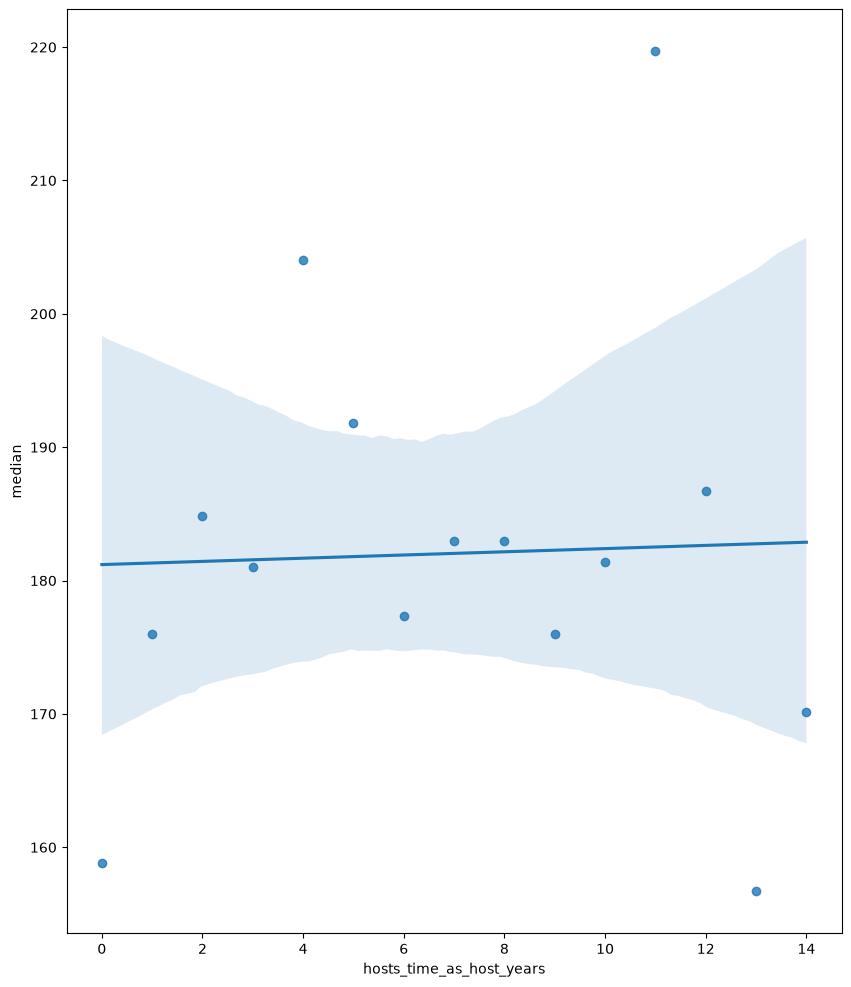

the rho is -0.030411497677494, the p value is 0.914321900505203


In [58]:
hosts_years_median_price = df.groupby('hosts_time_as_host_years')['price'].agg(['count', 'median']).query('count>500').sort_index()

plt.clf()
plt.figure(figsize=(10, 12))
sns.regplot(data = hosts_years_median_price, x = hosts_years_median_price.index, y = 'median')
plt.show()

rho, p = spearmanr(hosts_years_median_price.index, hosts_years_median_price['median'])
print("the rho is {}, the p value is {}".format(rho, p))

In [59]:
hosts_years_median_price

,count,median
hosts_time_as_host_years,,
0.0,7982,158.850
1.0,7691,176.000
2.0,8580,184.870
3.0,6959,181.000
4.0,4104,204.000
5.0,1828,191.800
6.0,3226,177.375
7.0,3908,183.000
8.0,3507,183.000


The results show very little evidence of an association between host experience and listing price. The median price varies across the different levels of host experience, ranging from approximately `$157` for hosts with `13` years of experience to `$220` for those with `11` years, but there is no clear upward or downward trend. The Spearman correlation of `ρ = -0.030` is close to zero, with a `p value of 0.914`, indicating no statistically significant relationship between the length of time a host has been active and median listing price. This suggests that, within this dataset, host experience alone is not strongly associated with listing price.

### Listing Performance

#### Guest Ratings

The final variable that I will measure for the EDA is `review_scores_rating`. This feature contains averaged user-reviews for each listing in the dataset. Higher ratings may be associated with higher prices due to a better quality, services or amenities. I will again begin by viewing the distribution of the feature and follow with viewing the median price for each rating. 

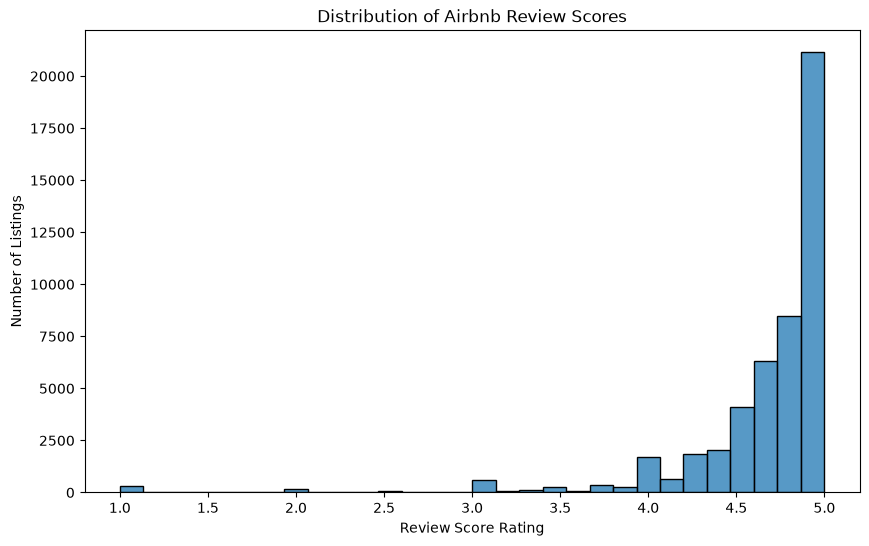

In [60]:
plt.figure(figsize=(10,6))

sns.histplot(data=df, x='review_scores_rating', bins=30)
plt.xlabel('Review Score Rating')
plt.ylabel('Number of Listings')
plt.title('Distribution of Airbnb Review Scores')

plt.show()

The distribution of the user-ratings is highly skewed, with the majority of ratings receiving a score of 4.5 or above. A rating of `5.0` is by far the most common having a count of `12648`, followed by a rating of `4.0` with a count of `1605` and `4.50` with a count of `1565`. Lower rated listings are rare in comparison, with a rating of `3.0` having a count of `579` and a rating of `2.0` having a count of `164`. This suggests that the ratings variable is strongly skewed towards positive reviews, which is important to consider when investigating its relationship with listing price.

In [61]:
rating_price = (df[['review_scores_rating','log_price']].dropna())

rating_price.head()

,review_scores_rating,log_price
0,4.55,5.457456
1,4.86,4.844187
2,4.81,4.923624
3,4.77,6.407985
4,4.42,4.223910


<Figure size 640x480 with 0 Axes>

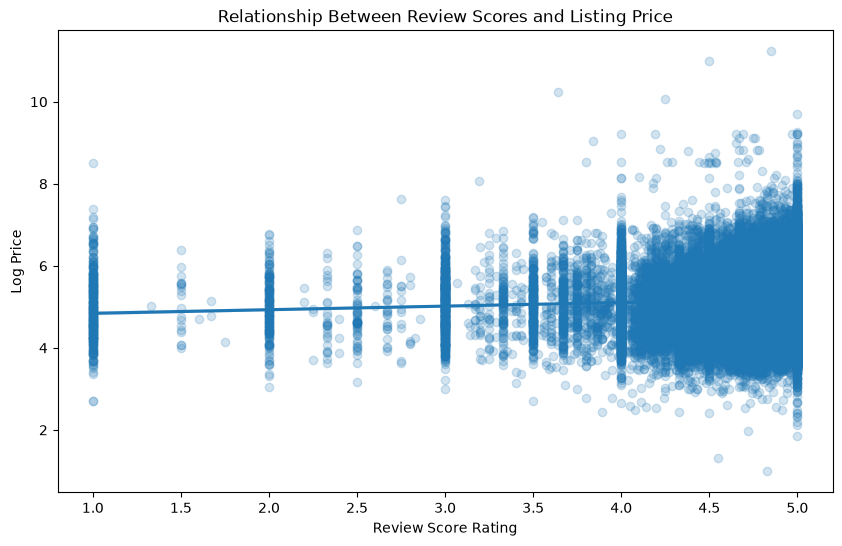

The rho is 0.06458292671818706, the p value is 3.756263497873664e-46


In [62]:
plt.clf()
plt.figure(figsize=(10,6))
sns.regplot(data=rating_price, x='review_scores_rating', y='log_price', scatter_kws={'alpha':0.2})

plt.xlabel('Review Score Rating')
plt.ylabel('Log Price')
plt.title('Relationship Between Review Scores and Listing Price')

plt.show()

rho, p = spearmanr(
    rating_price['review_scores_rating'],
    rating_price['log_price']
)

print("The rho is {}, the p value is {}".format(rho,p))

The results show a statistically significant but weak positive correlation between `review_scores_rating` and `log_price`. The results of the spearman's rank show a correlation of `ρ = ~0.065` and a `p value of 3.756 x 10⁻⁴⁶`. This indicates that listings with a higher user-rating do tend to have a slightly higher price, although the strength of this relationship is minimal. 

The prior distribution graph showed that the user-ratings are highly concentrated to the upper values, so while the spread of prices appears similar for properties with a lower user-rating, they should be interpreted with caution as it's likely the median pricings for the lower-rated listings are more influenced by individual observations. 

It therefore appears that `review_scores_rating` has limited explanatory power for listing price compared with factors such as location and property characteristics.